In [1]:
method='baseline' # this method is corresponding to bulkNN described in the paper


In [28]:
method='LINGER'


In [29]:
import scanpy as sc
#set some figure parameters for nice display inside jupyternotebooks.
%matplotlib inline
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(5, 5), facecolor='white')
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
#results_file = "scRNA/pbmc10k.h5ad"
import scipy
import pandas as pd
matrix=scipy.io.mmread('/home/qyyuan/project/Nature-Protocol/mouse/mm10_data/matrix.mtx')
features=pd.read_csv('/home/qyyuan/project/Nature-Protocol/mouse/mm10_data/features.txt',sep='\t',header=None)
barcodes=pd.read_csv('/home/qyyuan/project/Nature-Protocol/mouse/mm10_data/barcodes.txt',sep='\t',header=None)
label=pd.read_csv('/home/qyyuan/project/Nature-Protocol/mouse/mm10_data/mm10_label.txt',sep='\t',header=None)
label.columns=['barcode_use','label']  
from LingerGRN.preprocess import *
adata_RNA,adata_ATAC=get_adata(matrix,features,barcodes,label)# adata_RNA and adata_ATAC are scRNA and scATAC

backends is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
`set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
Tensorflow not installed; ParametricUMAP will be unavailable


scanpy==1.9.5 anndata==0.9.2 umap==0.5.7 numpy==1.24.3 scipy==1.11.3 pandas==2.0.3 scikit-learn==1.3.0 statsmodels==0.14.1 pynndescent==0.5.13


Trying to modify attribute `.obs` of view, initializing view as actual.
Trying to modify attribute `.obs` of view, initializing view as actual.


In [ ]:
adata_RNA.obs['barcode'].value

In [30]:
import scanpy as sc
sc.pp.filter_cells(adata_RNA, min_genes=200)
sc.pp.filter_genes(adata_RNA, min_cells=3)
sc.pp.filter_cells(adata_ATAC, min_genes=200)
sc.pp.filter_genes(adata_ATAC, min_cells=3)
selected_barcode=list(set(adata_RNA.obs['barcode'].values)&set(adata_ATAC.obs['barcode'].values))
barcode_idx=pd.DataFrame(range(adata_RNA.shape[0]), index=adata_RNA.obs['barcode'].values)
adata_RNA = adata_RNA[barcode_idx.loc[selected_barcode][0]]
barcode_idx=pd.DataFrame(range(adata_ATAC.shape[0]), index=adata_ATAC.obs['barcode'].values)
adata_ATAC = adata_ATAC[barcode_idx.loc[selected_barcode][0]]

Trying to modify attribute `.obs` of view, initializing view as actual.


filtered out 5593 genes that are detected in less than 3 cells
filtered out 116 cells that have less than 200 genes expressed


Trying to modify attribute `.obs` of view, initializing view as actual.


In [37]:
adata_RNA

View of AnnData object with n_obs × n_vars = 24819 × 26679
    obs: 'barcode', 'sample', 'label', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [36]:
barcode_idx

,0
4_5M_2_CTGTTCATCTCGACCT-1,0
1M_1_CCATAAGGTGGTTCCC-1,1
6M_ATTGCGCCATAAGCAA-1,2
4_5M_1_TAACCGGTCCTGGTGA-1,3
2_5M_4_TACATCAAGGACGTAA-1,4
...,...
3_5M_1_GGTTAGCGTTGCGTAA-1,24814
4_5M_2_AGTCAAGAGATAACCC-1,24815
4_5M_2_CTCAGGATCCGTAAAC-1,24816
4_5M_1_CCACACAAGCTACTGG-1,24817


In [35]:
selected_barcode

['4_5M_2_CTGTTCATCTCGACCT-1',
 '1M_1_CCATAAGGTGGTTCCC-1',
 '6M_ATTGCGCCATAAGCAA-1',
 '4_5M_1_TAACCGGTCCTGGTGA-1',
 '2_5M_4_TACATCAAGGACGTAA-1',
 '3_5M_2_ACCACATAGGTCGATT-1',
 '2W_2_TTGCAGCCAGTAGGAT-1',
 '2_5M_4_CCCTAATGTTAAGGCC-1',
 '1M_1_CTAACCTGTTTATTCG-1',
 '4_5M_1_TAGCCTGAGGCTACTG-1',
 '4_5M_1_GTGTCCAAGTGACCTG-1',
 '6M_TATGCATCACTGACCG-1',
 '1M_2_CTGTGTGAGTGAGGTA-1',
 '4_5M_2_CAACCCGCATAGACTT-1',
 '4_5M_1_GCAAACTTCTAGCTAA-1',
 '1M_1_TTGTGAGGTGAGCACT-1',
 '4_5M_2_CGTTGCGCAATAGCCC-1',
 '6M_GCGGAACCACTATGGC-1',
 '3_5M_2_TGGCCAATCGGCCATA-1',
 '6M_ACTAACTCAACTAGCC-1',
 '4_5M_1_CGCTTACTCCTCCATA-1',
 '3_5M_2_CGTAACCCATCGTTCT-1',
 '4_5M_1_TCGTGCTTCCTCCTAA-1',
 '1M_2_CCATAATCATGTTTGG-1',
 '1M_1_TTAAGGTGTTTAGTCC-1',
 '4_5M_2_TTATCCGTCTCGACCT-1',
 '1M_2_TATTTGCTCGTTTCTG-1',
 '3_5M_2_CGGAGTCTCCTGGTCT-1',
 '3_5M_2_GATAGACCAAACGGGC-1',
 '2_5M_4_AAGCATGAGTTATGGC-1',
 '4_5M_1_TGGTTCCTCTGGCATG-1',
 '2W_1_AAAGCTTGTCCTAACT-1',
 '1M_1_GGTTTCCTCCAAATCA-1',
 '2_5M_4_GATTTGCAGTTAACCA-1',
 '4_5M_2_GGAACCT

In [34]:
adata_RNA.obs['barcode'].shape

(24819,)

In [40]:
adata_ATAC.obs['sample'].values

array([1, 1, 1, ..., 1, 1, 1])

In [42]:
samplelist=list(set(adata_ATAC.obs['sample'].values)) # sample is generated from cell barcode 
tempsample=samplelist[0]

In [44]:
tempsample

1

In [43]:
samplelist

[1]

In [46]:
from LingerGRN.pseudo_bulk import *
samplelist=list(set(adata_ATAC.obs['sample'].values)) # sample is generated from cell barcode 
tempsample=samplelist[0]
TG_pseudobulk=pd.DataFrame([])
RE_pseudobulk=pd.DataFrame([])
singlepseudobulk = (adata_RNA.obs['sample'].unique().shape[0]*adata_RNA.obs['sample'].unique().shape[0]>100)
for tempsample in samplelist:
    adata_RNAtemp=adata_RNA[adata_RNA.obs['sample']==tempsample]
    adata_ATACtemp=adata_ATAC[adata_ATAC.obs['sample']==tempsample]
    TG_pseudobulk_temp,RE_pseudobulk_temp=pseudo_bulk(adata_RNAtemp,adata_ATACtemp,singlepseudobulk)                
    TG_pseudobulk=pd.concat([TG_pseudobulk, TG_pseudobulk_temp], axis=1)
    RE_pseudobulk=pd.concat([RE_pseudobulk, RE_pseudobulk_temp], axis=1)
    RE_pseudobulk[RE_pseudobulk > 100] = 100

import os
if not os.path.exists('data/'):
    os.mkdir('data/')
adata_ATAC.write('data/adata_ATAC.h5ad')
adata_RNA.write('data/adata_RNA.h5ad')
TG_pseudobulk=TG_pseudobulk.fillna(0)
RE_pseudobulk=RE_pseudobulk.fillna(0)
pd.DataFrame(adata_ATAC.var['gene_ids']).to_csv('data/Peaks.txt',header=None,index=None)
TG_pseudobulk.to_csv('data/TG_pseudobulk.tsv')
RE_pseudobulk.to_csv('data/RE_pseudobulk.tsv')

Received a view of an AnnData. Making a copy.


normalizing counts per cell
    finished (0:00:00)
filtered out 6 genes that are detected in less than 3 cells
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


Received a view of an AnnData. Making a copy.


... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    on highly variable genes
    with n_comps=15
    finished (0:00:03)


Received a view of an AnnData. Making a copy.


extracting highly variable genes
    finished (0:00:11)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


Received a view of an AnnData. Making a copy.


... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    on highly variable genes
    with n_comps=15
    finished (0:00:38)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:18)


In [1]:
import scanpy as sc
adata_ATAC=sc.read('data/adata_ATAC.h5ad')
adata_RNA=sc.read('data/adata_RNA.h5ad')

In [49]:
adata_RNA

AnnData object with n_obs × n_vars = 24819 × 26679
    obs: 'barcode', 'sample', 'label', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [50]:
adata_ATAC

AnnData object with n_obs × n_vars = 24819 × 328381
    obs: 'barcode', 'sample', 'label', 'n_genes'
    var: 'gene_ids', 'n_cells'

In [51]:
genomemap

,genome_short,species,species_ensembl,genome,release,Motif
genome_short,,,,,,
canFam3,canFam3,dog,Canis_lupus_familiaris,CanFam3,102,Mammal
danRer11,danRer11,zebrafish,Danio_rerio,GRCz11,102,Mammal
danRer10,danRer10,zebrafish,Danio_rerio,GRCz10,80,Mammal
dm6,dm6,fly,Drosophila_melanogaster,BDGP6,102,fly
dm3,dm3,fly,Drosophila_melanogaster,BDGP5,75,fly
rheMac8,rheMac8,rhesus,Macaca_mulatta,Mmul_8,97,Mammal
mm10,mm10,mouse,Mus_musculus,GRCm38,102,Mammal
mm9,mm9,mouse,Mus_musculus,NCBIM37,54,Mammal
rn5,rn5,rat,Rattus_norvegicus,Rnor_5,77,Mammal


In [53]:
Datadir='/home/qyyuan/data/TF_TG_software/code/mm10/'# This directory should be the same as Datadir defined in the above 'Download the general gene regulatory network' section
GRNdir=Datadir+'provide_data/'
genome='mm10'
outdir='/home/qyyuan/project/Nature-Protocol/MM10-results-p-Last/' #output dir
activef='ReLU' 
method='scNN'
import torch
import subprocess
import pandas as pd
import os
import LingerGRN.LINGER_tr as LINGER_tr
LINGER_tr.get_TSS(GRNdir,genome,200000) # Here, 200000 represent the largest distance of regulatory element to the TG. Other distance is supported
LINGER_tr.RE_TG_dis(outdir)
import LingerGRN.LINGER_tr as LINGER_tr
activef='ReLU' # active function chose from 'ReLU','sigmoid','tanh'
genomemap=pd.read_csv(GRNdir+'genome_map_homer.txt',sep='\t')
genomemap.index=genomemap['genome_short']
species=genomemap.loc[genome]['species_ensembl']
LINGER_tr.training(GRNdir,method,outdir,activef,species)

Overlap the regions with gene loc ...


***** WARNING: File /home/qyyuan/project/Nature-Protocol/mouse/data/Peaks.bed has inconsistent naming convention for record:
GL456211.1	116040	116319

***** WARNING: File /home/qyyuan/project/Nature-Protocol/mouse/data/Peaks.bed has inconsistent naming convention for record:
GL456211.1	116040	116319

100%|██████████| 21/21 [7:28:12<00:00, 1280.58s/it]  


In [2]:
import subprocess


In [3]:
Datadir='/home/qyyuan/data/TF_TG_software/code/mm10/'# This directory should be the same as Datadir defined in the above 'Download the general gene regulatory network' section
GRNdir=Datadir+'provide_data/'
genome='mm10'
outdir='/home/qyyuan/project/Nature-Protocol/MM10-results-p-Last/' #output dir
activef='ReLU' 
method='scNN'

In [4]:
GRNdir

'/home/qyyuan/data/TF_TG_software/code/mm10/provide_data/'

In [5]:
weights_only=True

In [6]:
adata_RNA

AnnData object with n_obs × n_vars = 24819 × 26679
    obs: 'barcode', 'sample', 'label', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [7]:
adata_ATAC

AnnData object with n_obs × n_vars = 24819 × 328381
    obs: 'barcode', 'sample', 'label', 'n_genes'
    var: 'gene_ids', 'n_cells'

In [26]:
import LingerGRN.LL_net as LL_net
TF_RE_binding(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)

Generating cellular population TF binding strength ...


[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.
[Parallel(n_jobs=23)]: Done   3 out of  21 | elapsed:  2.1min remaining: 12.5min
[Parallel(n_jobs=23)]: Done   6 out of  21 | elapsed:  2.4min remaining:  6.1min
[Parallel(n_jobs=23)]: Done   9 out of  21 | elapsed:  3.1min remaining:  4.1min
[Parallel(n_jobs=23)]: Done  12 out of  21 | elapsed:  3.6min remaining:  2.7min
[Parallel(n_jobs=23)]: Done  15 out of  21 | elapsed:  4.1min remaining:  1.7min
[Parallel(n_jobs=23)]: Done  18 out of  21 | elapsed:  4.2min remaining:   42.4s
[Parallel(n_jobs=23)]: Done  21 out of  21 | elapsed:  5.6min finished


In [7]:
cis_reg(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)


[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.
100%|██████████| 1617/1617 [00:01<00:00, 860.21it/s] 
[Parallel(n_jobs=23)]: Done   3 out of  21 | elapsed:   28.4s remaining:  2.8min
100%|██████████| 1004/1004 [00:02<00:00, 454.30it/s]
[Parallel(n_jobs=23)]: Done  21 out of  21 | elapsed:   42.0s finished


In [12]:
import LingerGRN.LL_net as LL_net
trans_reg(GRNdir,method,outdir,genome)


Generate trans-regulatory netowrk ...


[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.
[Parallel(n_jobs=23)]: Done   3 out of  21 | elapsed:   33.5s remaining:  3.4min
[Parallel(n_jobs=23)]: Done   6 out of  21 | elapsed:   38.3s remaining:  1.6min
[Parallel(n_jobs=23)]: Done   9 out of  21 | elapsed:   38.8s remaining:   51.8s
[Parallel(n_jobs=23)]: Done  12 out of  21 | elapsed:   39.5s remaining:   29.6s
[Parallel(n_jobs=23)]: Done  15 out of  21 | elapsed:   39.7s remaining:   15.9s
[Parallel(n_jobs=23)]: Done  18 out of  21 | elapsed:   40.8s remaining:    6.8s
[Parallel(n_jobs=23)]: Done  21 out of  21 | elapsed:   43.8s finished


Save trans-regulatory netowrk ...


In [ ]:
network = 'cell population'
from LingerGRN.TF_activity import *
TF_activity=regulon(outdir,adata_RNA,GRNdir,network,genome)
TF_activity.T.to_csv('/home/qyyuan/project/Nature-Protocol/PBMC/Figures/mouse_TFactivity.txt')


## TF activity

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
TF_activity=pd.DataFrame('/home/qyyuan/project/Nature-Protocol/PBMC/Figures/mouse_TFactivity.txt')
TF_activity = TF_activity.T
adata_RNA=sc.read('/home/qyyuan/project/Nature-Protocol/mouse/data/adata_RNA.h5ad')

AnnData object with n_obs × n_vars = 24819 × 26679
    obs: 'barcode', 'sample', 'label', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
Cells: 24819, Genes: 26679


/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:842: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


PCA subset shape: (24819, 14)


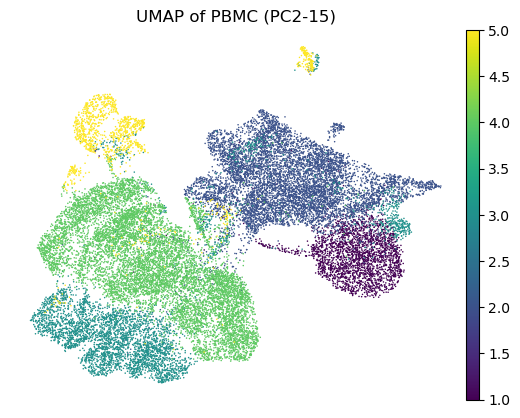

In [ ]:

# 1. 读取数据（如果还没有读取）
# adata = sc.read_h5ad('/path/to/adata_RNA.h5ad')

# 2. 查看数据基本信息
print(adata_RNA)
print(f"Cells: {adata_RNA.n_obs}, Genes: {adata_RNA.n_vars}")

# 3. 标准化和预处理
sc.pp.normalize_total(adata_RNA, target_sum=1e4)
sc.pp.log1p(adata_RNA)

# 4. 高变基因选择
sc.pp.highly_variable_genes(adata_RNA, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata_RNA.raw = adata_RNA
adata_RNA = adata_RNA[:, adata_RNA.var.highly_variable]

# 5. 数据缩放
sc.pp.scale(adata_RNA, max_value=10)
# ... 前面的预处理代码相同 ...

# 6. PCA 降维（先算多一点）
sc.tl.pca(adata_RNA, n_comps=30, svd_solver='arpack')

# ===== 7. 只取 PC2 到 PC15（索引 1 到 14） =====


/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


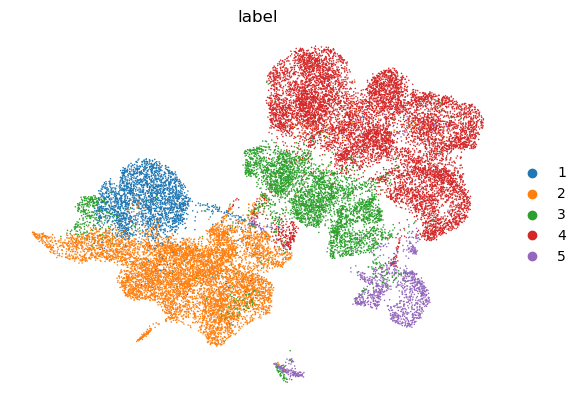

In [ ]:
adata_RNA.obs_names=adata_RNA.obs['barcode']
pca_subset = adata_RNA.obsm['X_pca'][:, 1:20]  # 跳过第1列（PC1）
print(f"PCA subset shape: {pca_subset.shape}")  # (n_cells, 14)

# 存入新的表示
adata_RNA.obsm['X_pca_2_15'] = pca_subset

# ===== 8. 使用这个子集计算邻居 =====
sc.pp.neighbors(adata_RNA, use_rep='X_pca_2_15', n_neighbors=15)

# 9. 计算 UMAP
sc.tl.umap(adata_RNA)

# 10. 绘制 UMAP
# 将 label 转换为 categorical 类型
adata_RNA.obs['label'] = adata_RNA.obs['label'].astype('category')

# 绘制 UMAP
sc.pl.umap(adata_RNA, color='label', frameon=False)
plt.show()

/home/qyyuan/.conda/envs/LINGER-Perellel/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


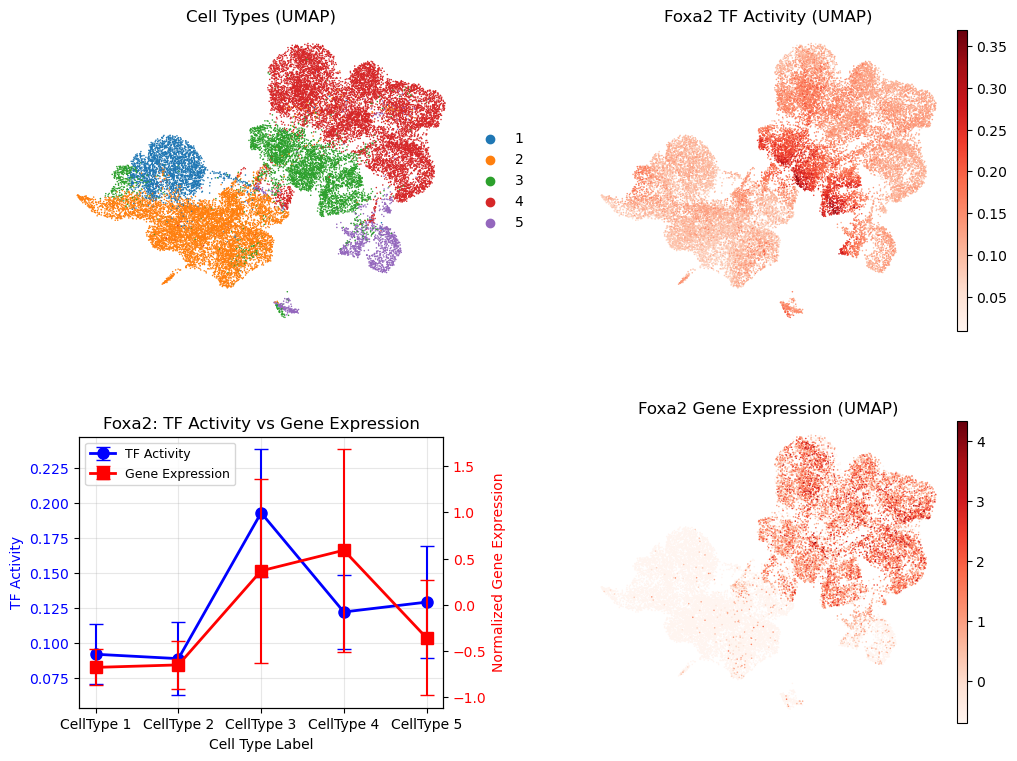

In [74]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

# ===== 确保 UMAP 已计算 =====
if 'X_umap' not in adata_RNA.obsm:
    print("Computing UMAP...")
    sc.tl.umap(adata_RNA)

# ===== 准备 Foxa2 数据 =====
foxa2_activity = TF_activity.loc['Foxa2'].reindex(adata_RNA.obs_names).values
adata_RNA.obs['Foxa2_activity'] = foxa2_activity

if 'Foxa2' in adata_RNA.var_names:
    foxa2_expr = adata_RNA[:, 'Foxa2'].X.toarray().flatten()
else:
    print("Foxa2 not found in var_names")
    foxa2_expr = np.zeros(len(adata_RNA))

# ===== 计算统计量 =====
labels = adata_RNA.obs['label'].values
unique_labels = sorted(set(labels))

activity_means, activity_stds = [], []
expr_means, expr_stds = [], []

for label in unique_labels:
    mask = (labels == label)
    activity_means.append(np.mean(foxa2_activity[mask]))
    activity_stds.append(np.std(foxa2_activity[mask]))
    expr_means.append(np.mean(foxa2_expr[mask]))
    expr_stds.append(np.std(foxa2_expr[mask]))

# ===== 创建 2×2 网格 =====
fig = plt.figure(figsize=(12, 9))
gs = GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.3)

# ===== 子图1：UMAP - label =====
ax1 = fig.add_subplot(gs[0, 0])
sc.pl.umap(
    adata_RNA,
    color='label',
    frameon=False,
    title='Cell Types',
    ax=ax1,
    show=False
)
ax1.set_title('Cell Types (UMAP)', fontsize=12)

# ===== 子图2：UMAP - Foxa2 TF Activity =====
ax2 = fig.add_subplot(gs[0, 1])
sc.pl.embedding(
    adata_RNA,
    basis='umap',
    color='Foxa2_activity',
    cmap='Reds',
    ax=ax2,
    show=False,
    frameon=False,
    title='Foxa2 TF Activity'
)
ax2.set_title('Foxa2 TF Activity (UMAP)', fontsize=12)

# ===== 子图4（原折线图）放到左下角 (gs[1, 0]) =====
pos = gs[1, 0].get_position(fig)
center_x = (pos.x0 + pos.x1) / 2
center_y = (pos.y0 + pos.y1) / 2
width = (pos.x1 - pos.x0) * 0.9
height = (pos.y1 - pos.y0) * 0.9

ax4 = fig.add_axes([center_x - width/2, center_y - height/2, width, height])

x = unique_labels

ax4_left = ax4
ax4_left.errorbar(
    x, activity_means, yerr=activity_stds,
    marker='o', markersize=8, linewidth=2,
    color='blue', ecolor='blue', elinewidth=1.5, capsize=5,
    label='TF Activity'
)
ax4_left.set_xlabel('Cell Type Label', fontsize=10)
ax4_left.set_ylabel('TF Activity', fontsize=10, color='blue')
ax4_left.tick_params(axis='y', labelcolor='blue')
ax4_left.set_xticks(x)
ax4_left.set_xticklabels([f'CellType {i}' for i in x])
ax4_left.grid(True, alpha=0.3)

ax4_right = ax4_left.twinx()
ax4_right.errorbar(
    x, expr_means, yerr=expr_stds,
    marker='s', markersize=8, linewidth=2,
    color='red', ecolor='red', elinewidth=1.5, capsize=5,
    label='Gene Expression'
)
ax4_right.set_ylabel('Normalized Gene Expression', fontsize=10, color='red')
ax4_right.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax4_left.get_legend_handles_labels()
lines2, labels2 = ax4_right.get_legend_handles_labels()
ax4_left.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax4.set_title('Foxa2: TF Activity vs Gene Expression', fontsize=12)

# ===== 子图3：UMAP - Foxa2 Gene Expression 放到右下角 (gs[1, 1]) =====
# 缩放到 0.9 倍并居中
pos = gs[1, 1].get_position(fig)
center_x = (pos.x0 + pos.x1) / 2
center_y = (pos.y0 + pos.y1) / 2
width = (pos.x1 - pos.x0) * 1
height = (pos.y1 - pos.y0) * 1

ax3 = fig.add_axes([center_x - width/2, center_y - height/2, width, height])

if 'Foxa2' in adata_RNA.var_names:
    sc.pl.embedding(
        adata_RNA,
        basis='umap',
        color='Foxa2',
        cmap='Reds',
        ax=ax3,
        show=False,
        frameon=False,
        title='Foxa2 Gene Expression',
        use_raw=False
    )
else:
    ax3.text(0.5, 0.5, 'Foxa2 not found', ha='center', va='center', fontsize=12)
ax3.set_title('Foxa2 Gene Expression (UMAP)', fontsize=12)

# ===== 保存 =====
plt.savefig('Foxa2_4panel_combined.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Foxa2_4panel_combined.png', dpi=300, bbox_inches='tight')
plt.show()